# Classification Using Decision Trees


## Loading Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

sn.set_palette("tab10")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the data
path = '/content/drive/MyDrive/Python/decision_tree/champo_samples.csv'
champo_df = pd.read_csv(path)

In [ ]:
# Sample check the data
champo_df.head()

,CustomerCode,USA,UK,Italy,Belgium,Romania,Australia,India,QtyRequired,Hand Tufted,...,Hand Woven,Knotted,Jacquard,Handloom,Other,REC,Round,Square,AreaFt,Order Conversion
0,CC,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1,...,0,0,0,0,0,1,0,0,80.0,1
1,M-1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,...,0,0,0,0,0,1,0,0,80.0,1
2,M-1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2,1,...,0,0,0,0,0,1,0,0,80.0,1
3,M-1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,...,0,0,0,0,0,1,0,0,80.0,1
4,M-1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,...,0,0,0,0,0,1,0,0,80.0,1


In [ ]:
# Get datatype and d null value information of the data
champo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5820 entries, 0 to 5819
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerCode      5820 non-null   object 
 1   USA               5781 non-null   float64
 2   UK                5781 non-null   float64
 3   Italy             5781 non-null   float64
 4   Belgium           5781 non-null   float64
 5   Romania           5781 non-null   float64
 6   Australia         5781 non-null   float64
 7   India             5781 non-null   float64
 8   QtyRequired       5820 non-null   int64  
 9   Hand Tufted       5820 non-null   int64  
 10  Durry             5820 non-null   int64  
 11  Double Back       5820 non-null   int64  
 12  Hand Woven        5820 non-null   int64  
 13  Knotted           5820 non-null   int64  
 14  Jacquard          5820 non-null   int64  
 15  Handloom          5820 non-null   int64  
 16  Other             5820 non-null   int64  


## EDA

In [ ]:
champo_df.describe()

,USA,UK,Italy,Belgium,Romania,Australia,India,QtyRequired,Hand Tufted,Durry,...,Hand Woven,Knotted,Jacquard,Handloom,Other,REC,Round,Square,AreaFt,Order Conversion
count,5781.000000,5781.000000,5781.000000,5781.000000,5781.000000,5781.000000,5781.000000,5820.000000,5820.000000,5820.000000,...,5820.000000,5820.000000,5820.000000,5820.000000,5820.000000,5820.000000,5820.000000,5820.000000,5820.000000,5820.000000
mean,0.249092,0.035115,0.007784,0.022833,0.003460,0.001730,0.681716,1.974914,0.416667,0.268557,...,0.121134,0.037285,0.014433,0.017698,0.029038,0.986426,0.009794,0.003780,21.555815,0.200859
std,0.432525,0.184086,0.087891,0.149385,0.058722,0.041559,0.465851,5.683137,0.493049,0.443247,...,0.326311,0.189476,0.119278,0.131861,0.167927,0.115724,0.098486,0.061371,21.548281,0.400677
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.666700,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,39.812500,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,200.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,480.000000,1.000000


In [ ]:
#Get chd value count
champo_df['Order Conversion'].value_counts()

,count
Order Conversion,
0,4651
1,1169


<Axes: xlabel='Order Conversion', ylabel='count'>

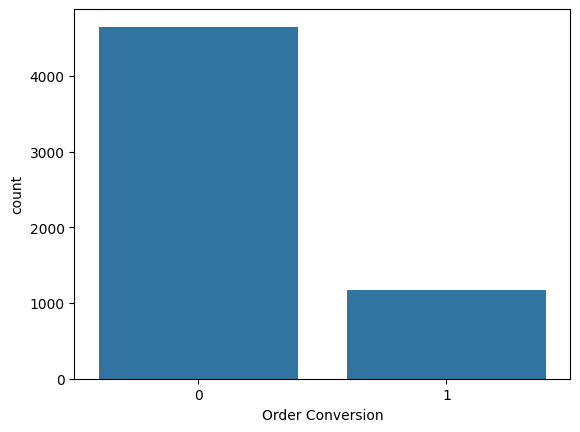

In [ ]:
#plot chd
sn.countplot(x = 'Order Conversion', data = champo_df)

## Train test split

In [ ]:
#Drop CustomerCode column from champo_df
champo_df.drop('CustomerCode', axis = 1, inplace = True)

In [ ]:
#Create dummy variable for categorical variable famhist
encoded_champo_df = champo_df
# encoded_champo_df = pd.get_dummies(champo_df, columns = ['famhist'],
#                                 drop_first = True,
#                                 dtype=int)

In [ ]:
encoded_champo_df.head(5)

,USA,UK,Italy,Belgium,Romania,Australia,India,QtyRequired,Hand Tufted,Durry,...,Hand Woven,Knotted,Jacquard,Handloom,Other,REC,Round,Square,AreaFt,Order Conversion
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1,0,...,0,0,0,0,0,1,0,0,80.0,1
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,...,0,0,0,0,0,1,0,0,80.0,1
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2,1,0,...,0,0,0,0,0,1,0,0,80.0,1
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,...,0,0,0,0,0,1,0,0,80.0,1
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,...,0,0,0,0,0,1,0,0,80.0,1


In [ ]:
#create train test split
from sklearn.model_selection import train_test_split

In [ ]:
#Create x_features
x_features = encoded_champo_df.drop('Order Conversion', axis = 1)

In [ ]:
#List for best_param - feature selection
X_features = list(encoded_champo_df.columns)
X_features.remove('Order Conversion')

In [ ]:
#create x train, x test, y train, y test
X_train, X_test, y_train, y_test = train_test_split(x_features,
                                                    encoded_champo_df['Order Conversion'],
                                                    test_size = 0.2,
                                                    random_state = 100)

In [ ]:
X_train.shape

(4656, 20)

In [ ]:
X_test.shape

(1164, 20)

## Build Decision Tree Model

In [ ]:
#Build decision tree
from sklearn.tree import DecisionTreeClassifier

In [ ]:
#build tree
tree = DecisionTreeClassifier(max_depth = 5, criterion='gini', min_samples_split = 100)

In [ ]:
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=50)

In [ ]:
y_pred = tree.predict(X_test)

In [ ]:
y_df = pd.DataFrame({"actual": y_test,
                     "predicted": y_pred})

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test, y_pred)

0.8676975945017182

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

In [ ]:
print(classification_report(y_df.actual, y_df.predicted))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       902
           1       0.86      0.49      0.63       262

    accuracy                           0.87      1164
   macro avg       0.86      0.73      0.77      1164
weighted avg       0.87      0.87      0.85      1164



In [ ]:
pred_probs = tree.predict_proba(X_test)
y_df['pred_probs'] = pred_probs[:, 1]

In [ ]:
y_df = pd.DataFrame({"actual": y_test,
                          "predicted": y_pred,
                          "pred_probs": pred_probs[:, 1]})

In [ ]:
y_df

,actual,predicted,pred_probs
4935,0,0,0.069278
1585,0,0,0.069278
887,0,0,0.069278
646,1,0,0.118881
3466,0,0,0.069278
...,...,...,...
1123,0,0,0.069278
5281,1,1,0.902913
4265,0,0,0.069278
3319,0,0,0.069278


<Axes: xlabel='pred_probs', ylabel='Density'>

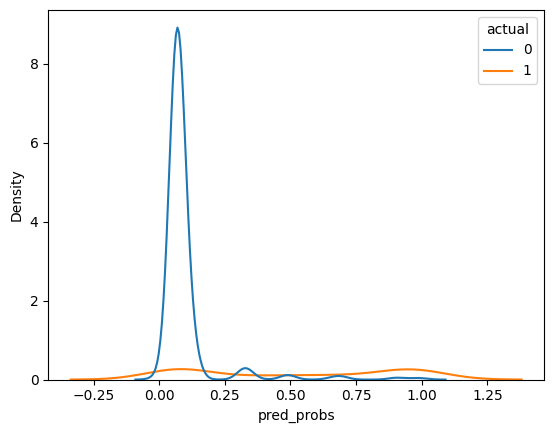

In [ ]:
#To check how well the probabilities are
sn.kdeplot(x = 'pred_probs', hue = 'actual', data = y_df)

In [ ]:
#roc_auc score and curve
from sklearn.metrics import roc_auc_score,RocCurveDisplay

In [ ]:
roc_auc_score(y_df.actual, y_df.pred_probs)

0.8093041756232968

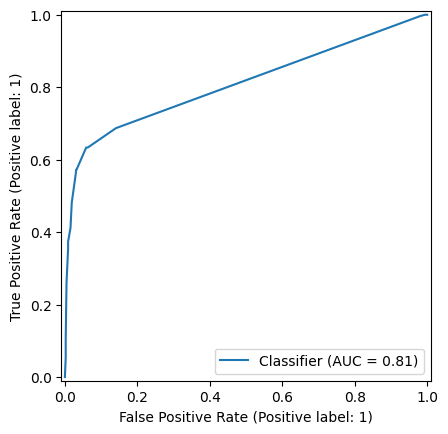

In [ ]:
#display ROC curve
RocCurveDisplay.from_predictions(y_df.actual, y_df.pred_probs);

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
cm = confusion_matrix(y_df.actual, y_df.predicted, labels=[1,0])

In [ ]:
cm_plot = ConfusionMatrixDisplay(cm, display_labels=['Converted', 'Not converted'])

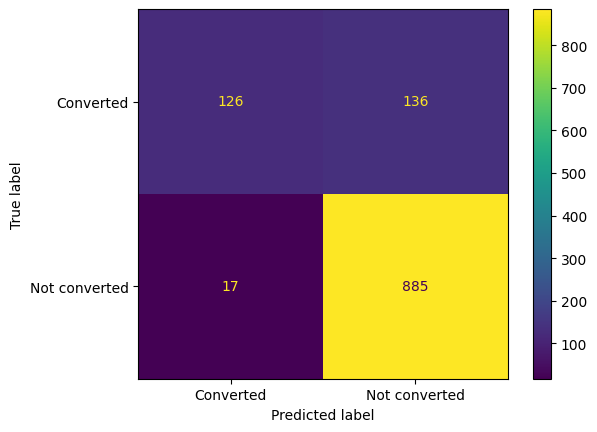

In [ ]:
cm_plot.plot();

In [ ]:
from sklearn.tree import plot_tree

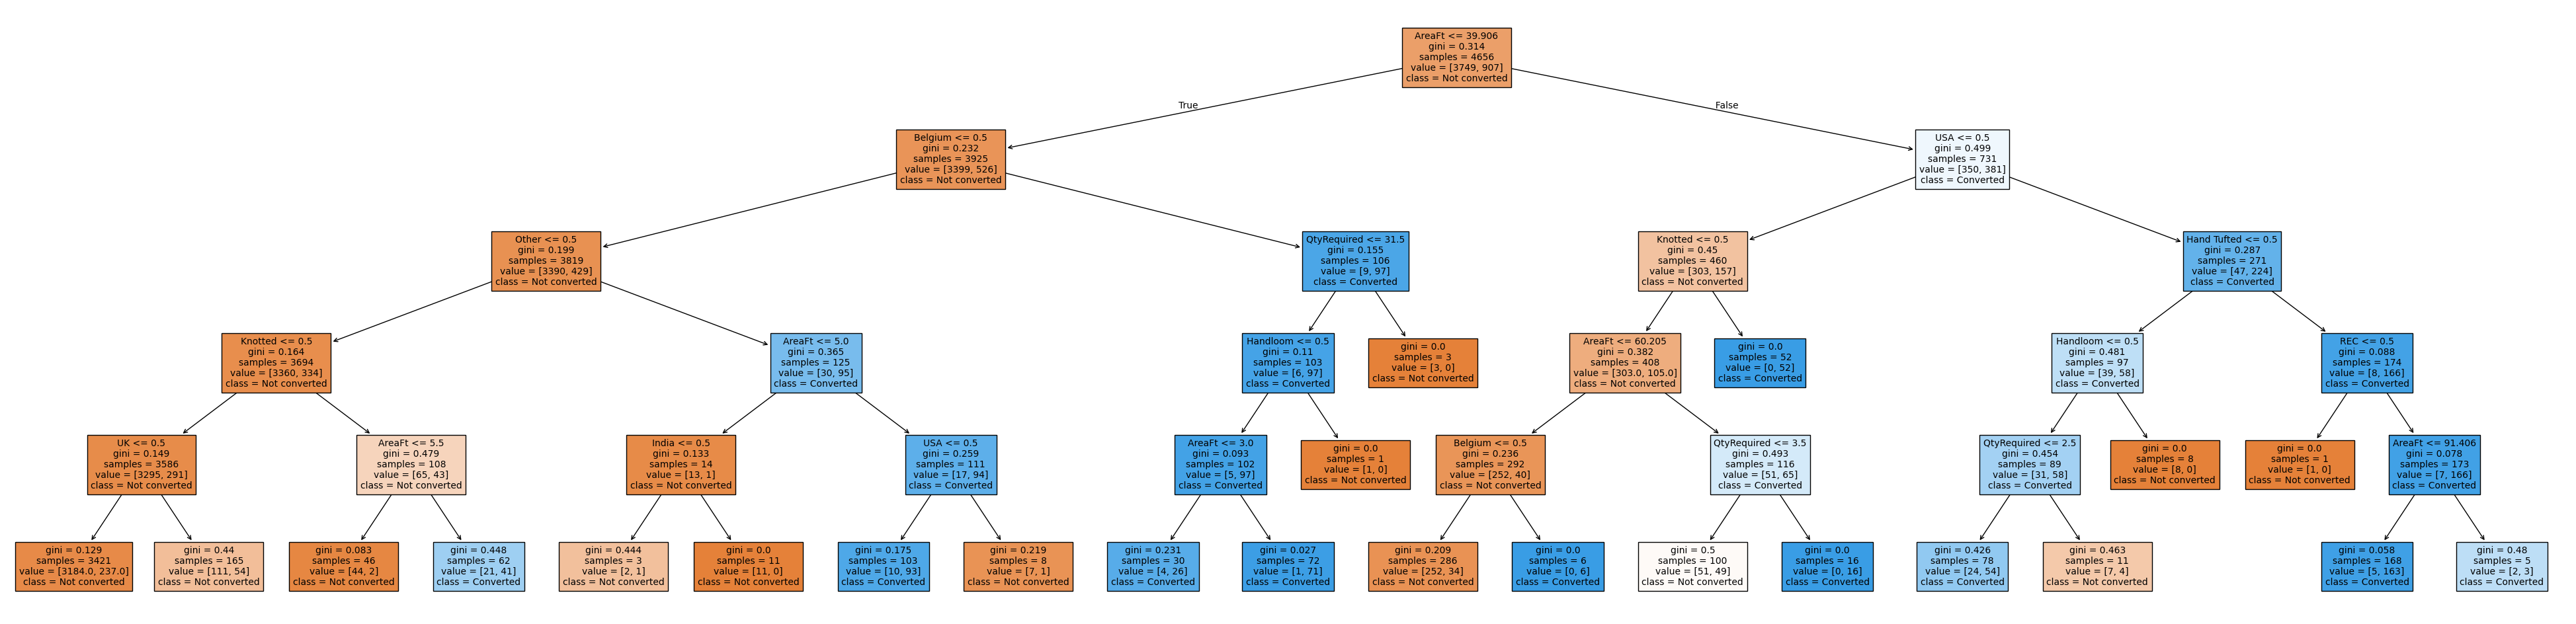

In [ ]:
plt.figure(figsize = (50, 12))
plot_tree(tree,
          feature_names = X_features,
          class_names = ['Not converted', 'Converted'],
          filled = True,
          fontsize = 10);
plt.savefig('tree.png')

## Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
params = {'max_depth': range(0, 20, 2),
          'criterion': ['gini', 'entropy']}

In [ ]:
grid_v1 = GridSearchCV(estimator = DecisionTreeClassifier(),
                     param_grid = params,
                     cv = 5,
                       scoring = 'recall')

In [ ]:
grid_v1.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(0, 20, 2)},
             scoring='recall')

In [ ]:
grid_results = pd.DataFrame(grid_v1.cv_results_)

In [ ]:
grid_results[grid_results.rank_test_score < 10]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
5,0.010062,0.000816,0.005558,0.000760,gini,10,"{'criterion': 'gini', 'max_depth': 10}",0.703297,0.679558,0.674033,0.718232,0.747253,0.704475,0.026714,1
6,0.010133,0.000596,0.004960,0.000063,gini,12,"{'criterion': 'gini', 'max_depth': 12}",0.675824,0.657459,0.690608,0.718232,0.714286,0.691282,0.022973,7
7,0.010781,0.000993,0.005631,0.000749,gini,14,"{'criterion': 'gini', 'max_depth': 14}",0.664835,0.668508,0.701657,0.712707,0.708791,0.691300,0.020452,5
8,0.010721,0.000641,0.005656,0.000752,gini,16,"{'criterion': 'gini', 'max_depth': 16}",0.664835,0.662983,0.707182,0.712707,0.708791,0.691300,0.022444,5
9,0.010203,0.000069,0.004876,0.000100,gini,18,"{'criterion': 'gini', 'max_depth': 18}",0.664835,0.668508,0.707182,0.718232,0.708791,0.693510,0.022266,4
16,0.009622,0.000208,0.004725,0.000088,entropy,12,"{'criterion': 'entropy', 'max_depth': 12}",0.681319,0.657459,0.674033,0.718232,0.725275,0.691263,0.026163,9
17,0.011665,0.002302,0.005663,0.001391,entropy,14,"{'criterion': 'entropy', 'max_depth': 14}",0.670330,0.651934,0.701657,0.712707,0.719780,0.691282,0.025947,8
18,0.009929,0.000260,0.004824,0.000321,entropy,16,"{'criterion': 'entropy', 'max_depth': 16}",0.670330,0.662983,0.712707,0.718232,0.719780,0.696807,0.024838,2
19,0.010063,0.000157,0.005105,0.000493,entropy,18,"{'criterion': 'entropy', 'max_depth': 18}",0.670330,0.662983,0.712707,0.712707,0.714286,0.694603,0.022943,3


In [ ]:
grid_results[['param_criterion',
              'param_max_depth',
              'mean_test_score',
              'std_test_score',
              'rank_test_score']].sort_values('rank_test_score', ascending = True)[0:10]

,param_criterion,param_max_depth,mean_test_score,std_test_score,rank_test_score
5,gini,10,0.704475,0.026714,1
18,entropy,16,0.696807,0.024838,2
19,entropy,18,0.694603,0.022943,3
9,gini,18,0.693510,0.022266,4
7,gini,14,0.691300,0.020452,5
8,gini,16,0.691300,0.022444,5
6,gini,12,0.691282,0.022973,7
17,entropy,14,0.691282,0.025947,8
16,entropy,12,0.691263,0.026163,9
15,entropy,10,0.687955,0.022871,10


In [ ]:
grid_v1.best_params_

{'criterion': 'gini', 'max_depth': 10}

In [ ]:
grid_v1.best_score_

0.704474530993868

In [ ]:
pd.DataFrame(grid_v1.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001668,0.001213,0.000000,0.000000,gini,0,"{'criterion': 'gini', 'max_depth': 0}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,19
1,0.005339,0.000160,0.004672,0.000363,gini,2,"{'criterion': 'gini', 'max_depth': 2}",0.401099,0.337017,0.342541,0.348066,0.368132,0.359371,0.023361,17
2,0.008165,0.001949,0.005328,0.001161,gini,4,"{'criterion': 'gini', 'max_depth': 4}",0.615385,0.524862,0.569061,0.574586,0.615385,0.579856,0.033744,16
3,0.008943,0.001743,0.004802,0.000273,gini,6,"{'criterion': 'gini', 'max_depth': 6}",0.593407,0.640884,0.629834,0.618785,0.631868,0.622955,0.016363,13
4,0.009361,0.000862,0.004855,0.000218,gini,8,"{'criterion': 'gini', 'max_depth': 8}",0.637363,0.651934,0.679558,0.662983,0.686813,0.663730,0.017991,11
5,0.010062,0.000816,0.005558,0.000760,gini,10,"{'criterion': 'gini', 'max_depth': 10}",0.703297,0.679558,0.674033,0.718232,0.747253,0.704475,0.026714,1
6,0.010133,0.000596,0.004960,0.000063,gini,12,"{'criterion': 'gini', 'max_depth': 12}",0.675824,0.657459,0.690608,0.718232,0.714286,0.691282,0.022973,7
7,0.010781,0.000993,0.005631,0.000749,gini,14,"{'criterion': 'gini', 'max_depth': 14}",0.664835,0.668508,0.701657,0.712707,0.708791,0.691300,0.020452,5
8,0.010721,0.000641,0.005656,0.000752,gini,16,"{'criterion': 'gini', 'max_depth': 16}",0.664835,0.662983,0.707182,0.712707,0.708791,0.691300,0.022444,5
9,0.010203,0.000069,0.004876,0.000100,gini,18,"{'criterion': 'gini', 'max_depth': 18}",0.664835,0.668508,0.707182,0.718232,0.708791,0.693510,0.022266,4


## Significant variables

In [ ]:
grid_v1.best_estimator_.feature_importances_

array([0.11574104, 0.02278465, 0.        , 0.14521986, 0.00149041,
       0.00104847, 0.02386194, 0.05280361, 0.04082689, 0.00792438,
       0.00362913, 0.01348494, 0.07354903, 0.00353956, 0.00876813,
       0.11891113, 0.00376555, 0.00182308, 0.00187165, 0.35895654])

In [ ]:
importance_df = pd.DataFrame({'feature': X_features,
                              'importance': grid_v1.best_estimator_.feature_importances_})

In [ ]:
importance_df = importance_df.sort_values('importance', ascending = False)
importance_df

,feature,importance
19,AreaFt,0.358957
3,Belgium,0.145220
15,Other,0.118911
0,USA,0.115741
12,Knotted,0.073549
7,QtyRequired,0.052804
8,Hand Tufted,0.040827
6,India,0.023862
1,UK,0.022785
11,Hand Woven,0.013485


## Build Decision Tree Model using best parameters and only important features

In [ ]:
# Create df_champo_imp
df_champo_imp = importance_df[importance_df['importance'] > 0.02]

# Get column names and trim mdf_champo
important_features = df_champo_imp['feature'].tolist()
mdf_champo = encoded_champo_df[important_features + ['Order Conversion']]

In [ ]:
#Create x_features
x_features = mdf_champo.drop('Order Conversion', axis = 1)

In [ ]:
#List for best_param - feature selection
X_features = list(encoded_champo_df.columns)
X_features.remove('Order Conversion')

In [ ]:
#create x train, x test, y train, y test
X_train, X_test, y_train, y_test = train_test_split(x_features,
                                                    encoded_champo_df['Order Conversion'],
                                                    test_size = 0.2,
                                                    random_state = 100)

In [ ]:
X_train.shape

(4656, 9)

In [ ]:
X_test.shape

(1164, 9)

In [ ]:
#build tree
tree = DecisionTreeClassifier(max_depth = 10, criterion='gini')

In [ ]:
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

In [ ]:
y_pred = tree.predict(X_test)

In [ ]:
y_df = pd.DataFrame({"actual": y_test,
                     "predicted": y_pred})

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test, y_pred)

0.8960481099656358

In [ ]:
print(classification_report(y_df.actual, y_df.predicted))

              precision    recall  f1-score   support

           0       0.90      0.97      0.94       902
           1       0.87      0.63      0.73       262

    accuracy                           0.90      1164
   macro avg       0.89      0.80      0.83      1164
weighted avg       0.89      0.90      0.89      1164



In [ ]:
pred_probs = tree.predict_proba(X_test)
y_df['pred_probs'] = pred_probs[:, 1]

In [ ]:
y_df = pd.DataFrame({"actual": y_test,
                          "predicted": y_pred,
                          "pred_probs": pred_probs[:, 1]})

In [ ]:
y_df

,actual,predicted,pred_probs
4935,0,0,0.000000
1585,0,0,0.119328
887,0,0,0.119328
646,1,0,0.000000
3466,0,0,0.119328
...,...,...,...
1123,0,0,0.066667
5281,1,1,1.000000
4265,0,0,0.006452
3319,0,0,0.066667


<Axes: xlabel='pred_probs', ylabel='Density'>

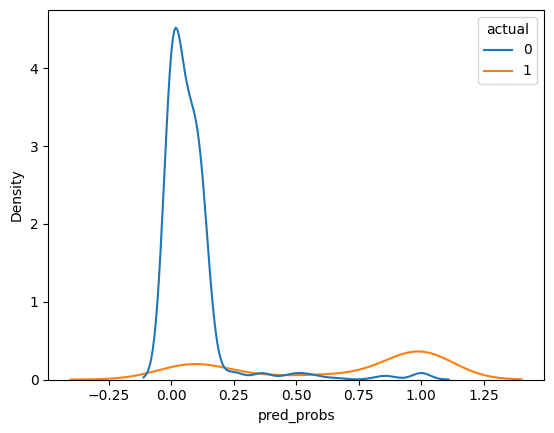

In [ ]:
#To check how well the probabilities are
sn.kdeplot(x = 'pred_probs', hue = 'actual', data = y_df)

In [ ]:
#roc_auc score and curve
from sklearn.metrics import roc_auc_score,RocCurveDisplay

In [ ]:
roc_auc_score(y_df.actual, y_df.pred_probs)

0.8839093786496504

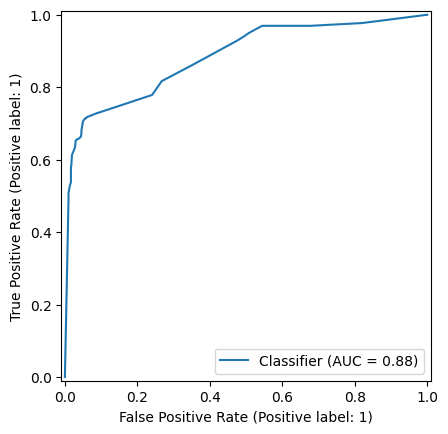

In [ ]:
#display ROC curve
RocCurveDisplay.from_predictions(y_df.actual, y_df.pred_probs);

In [ ]:
cm = confusion_matrix(y_df.actual, y_df.predicted, labels=[1,0])

In [ ]:
cm_plot = ConfusionMatrixDisplay(cm, display_labels=['Converted', 'Not converted'])

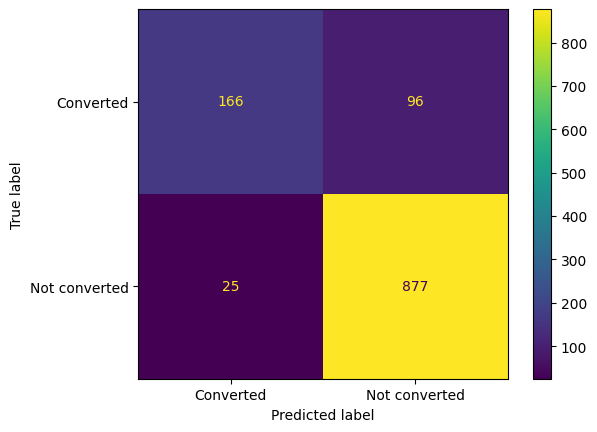

In [ ]:
cm_plot.plot();

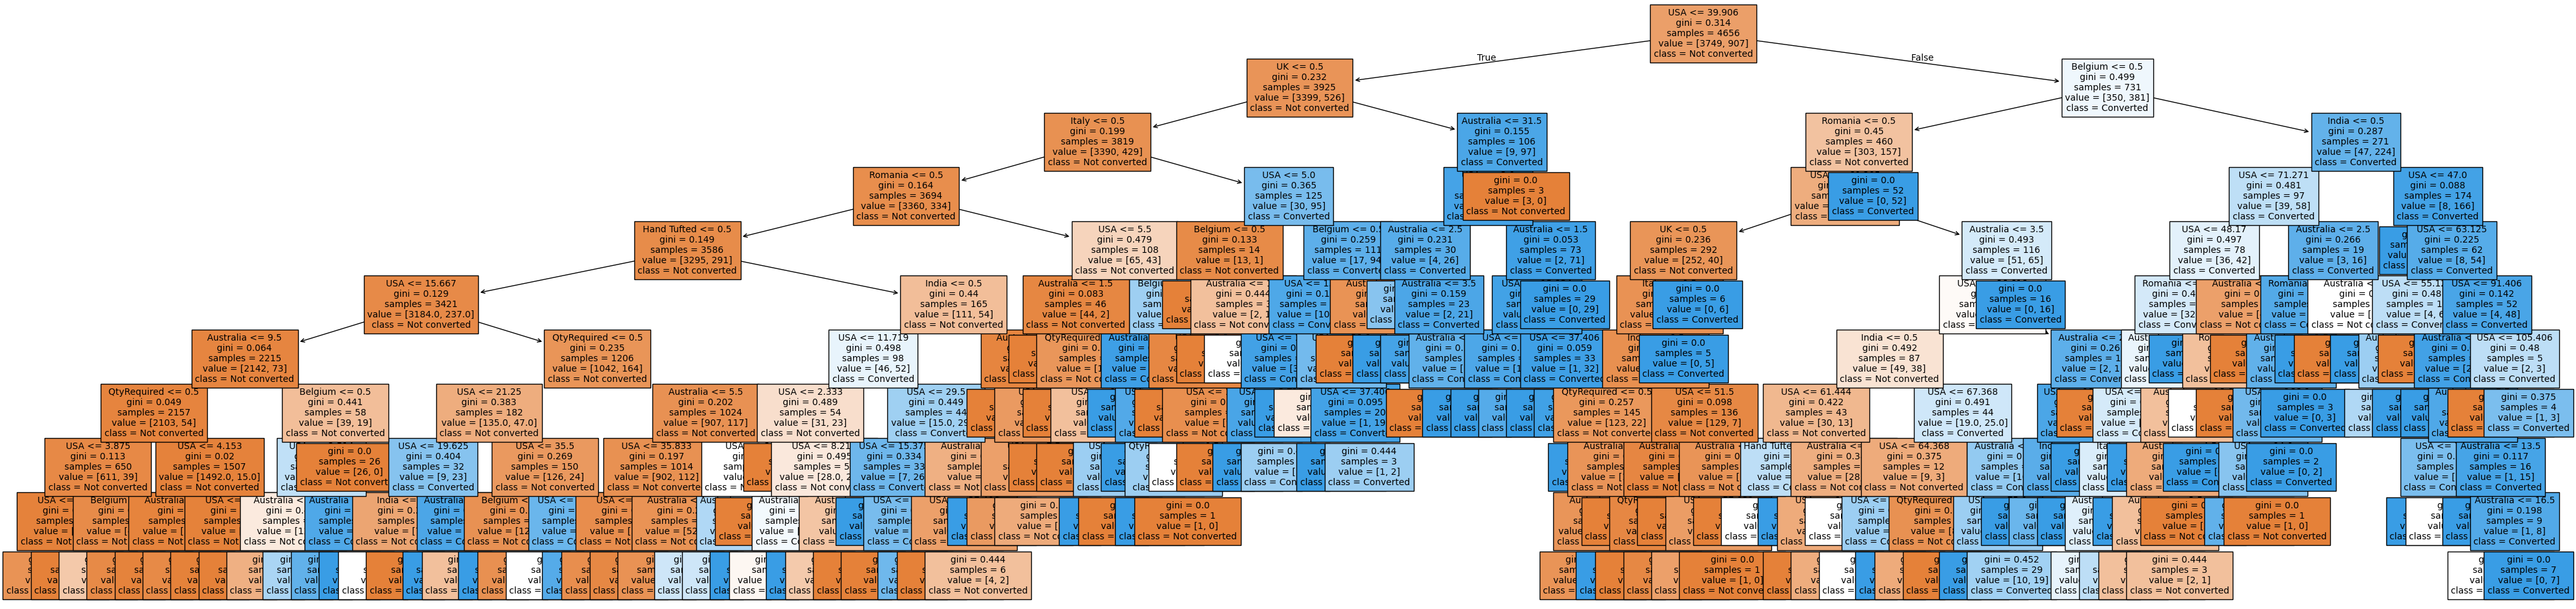

In [ ]:
plt.figure(figsize = (50, 12))
plot_tree(tree,
          feature_names = X_features,
          class_names = ['Not converted', 'Converted'],
          filled = True,
          fontsize = 10);
plt.savefig('tree.png')

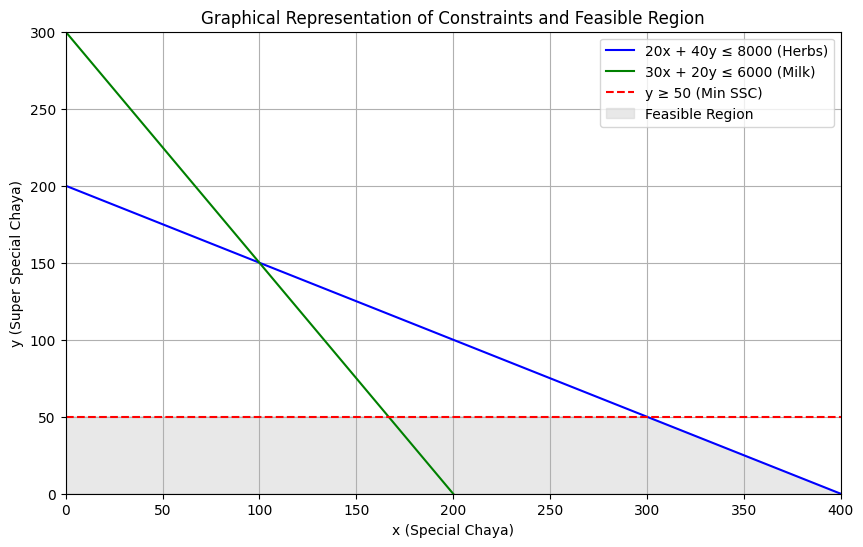

In [7]:
# Re-import necessary libraries after reset
import numpy as np
import matplotlib.pyplot as plt

# Define the constraints
x = np.linspace(0, 500, 500)

# Constraint 1: Herbs
x2_herbs = (8000 - 20 * x) / 40

# Constraint 2: Milk
x2_milk = (6000 - 30 * x) / 20

# Constraint 3: Minimum SSC
x2_min_ssc = np.full_like(x, 50)

# Feasibility region: bounds
y = np.minimum(np.minimum(x2_herbs, x2_milk), x2_min_ssc)
y = np.clip(y, 0, None)

# Plotting the constraints and feasible region
plt.figure(figsize=(10, 6))
plt.plot(x, x2_herbs, label="20x + 40y ≤ 8000 (Herbs)", color="blue")
plt.plot(x, x2_milk, label="30x + 20y ≤ 6000 (Milk)", color="green")
plt.axhline(y=50, color="red", linestyle="--", label="y ≥ 50 (Min SSC)")
plt.fill_between(x, 0, y, where=(y >= 0), color="lightgray", alpha=0.5, label="Feasible Region")

# Label axes and add legend
plt.xlabel("x (Special Chaya)")
plt.ylabel("y (Super Special Chaya)")
plt.title("Graphical Representation of Constraints and Feasible Region")
plt.xlim(0, 400)
plt.ylim(0, 300)
plt.legend()
plt.grid()
plt.show()

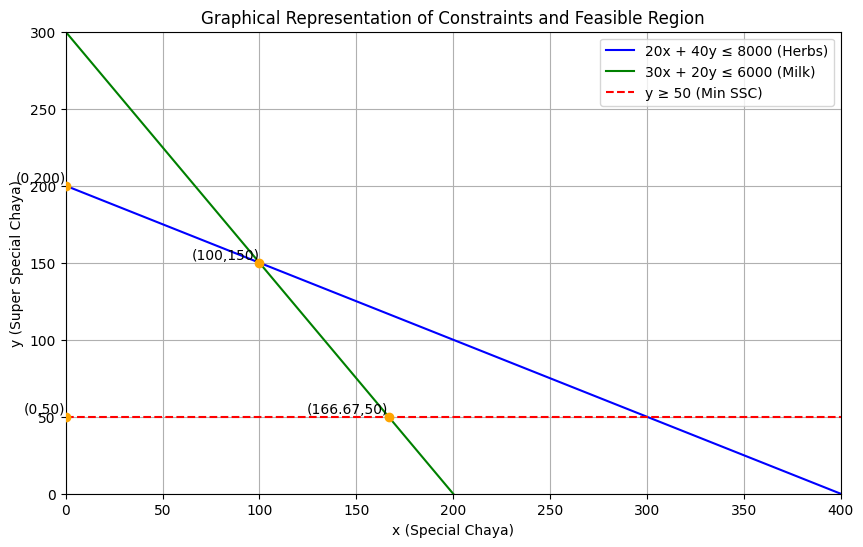

In [10]:
# Re-import necessary libraries after reset
import numpy as np
import matplotlib.pyplot as plt

# Define the constraints
x = np.linspace(0, 400, 500)  # Extend x range to capture all points

# Constraint 1: Herbs
x2_herbs = (8000 - 20 * x) / 40

# Constraint 2: Milk
x2_milk = (6000 - 30 * x) / 20

# Constraint 3: Minimum SSC
x2_min_ssc = np.full_like(x, 50)

# Feasibility region: bounds
y = np.minimum(np.minimum(x2_herbs, x2_milk), x2_min_ssc)
y = np.clip(y, 0, None)

# Plotting the constraints and feasible region
plt.figure(figsize=(10, 6))
plt.plot(x, x2_herbs, label="20x + 40y ≤ 8000 (Herbs)", color="blue")
plt.plot(x, x2_milk, label="30x + 20y ≤ 6000 (Milk)", color="green")
plt.axhline(y=50, color="red", linestyle="--", label="y ≥ 50 (Min SSC)")

# Highlighting specific feasible region points
plt.scatter([0, 0, 166.67, 100], [200, 50, 50, 150], color='orange', zorder=5)
plt.text(0, 200, '(0,200)', fontsize=10, verticalalignment='bottom', horizontalalignment='right')
plt.text(0, 50, '(0,50)', fontsize=10, verticalalignment='bottom', horizontalalignment='right')
plt.text(166.67, 50, '(166.67,50)', fontsize=10, verticalalignment='bottom', horizontalalignment='right')
plt.text(100, 150, '(100,150)', fontsize=10, verticalalignment='bottom', horizontalalignment='right')

# Label axes and add legend
plt.xlabel("x (Special Chaya)")
plt.ylabel("y (Super Special Chaya)")
plt.title("Graphical Representation of Constraints and Feasible Region")
plt.xlim(0, 400)
plt.ylim(0, 300)
plt.legend()
plt.grid()
plt.show()
